# Circuitos Eletrônicos I - T3
## Análise de Circuitos com Diodos

### Autor: João Victor Colombari Carlet

Neste notebook vamos analisar os circuitos propostos na lista de exercícios para o Teste 3.

### Ferramentas Utilizadas:
* **`ngspice`**: Nosso motor de simulação de backend, encarregado de resolver as equações matriciais não-lineares dos diodos.
* **`PySpice`**: A biblioteca de ponte que traduz comandos do Python para comandos interpretados pelo SPICE.

### Nota Didática: Como criar as netlists?
Em vez de programar cada nó e componente manualmente em SPICE, o que pode ser bem chato, adotamos um **fluxo híbrido**:
1. Você desenha o circuito visualmente no **LTspice**.
2. O próprio LTspice gera a lista de conexões (o arquivo texto de extensão `.net`) em view-SPICE Netlist.
3. A Netlist pode conter subcircuitos linkados na lib do LTSpice, o que gera algumas alterações manuais, onde alguma LLM pode ajudar.
3. Nós simplesmente lemos esse arquivo `.net` direto no notebook, o que facilita a manutenção e visualização.

> **Curiosidade sobre Design Visual:** Existe uma biblioteca chamada `schemdraw` para desenhar esquemáticos diretamente com código Python. No entanto, ela exige coordenadas geométricas precisas para cada fio, o que torna o processo muito complexo e demorado para fins educacionais, mas pode ser útil para algum trabalho futuro!

## Passo 0: Inicializando o Ambiente de Simulação e Gráficos


Vamos verificar se as ferramentas do `matplotlib` para gerar curvas de alta resolução, o leitor de arquivos (`SpiceParser`) do `PySpice`, e o numpy estão instalados e depois importar tudo.

> **Importante:** Para executar as simulações localmente, vocês vão precisar do ngspice instalado. Pelo OSX é só executar: 

```bash
brew install ngspice
```

No Linux:

```bash
sudo apt-get update
sudo apt-get install ngspice
```

No windows fico devendo, mas não deve ser dificil.. 

In [1]:
import sys
print(f"Ambiente ativo: {sys.executable}")

# Instalação silenciosa das dependências necessárias no kernel atual
!{sys.executable} -m pip -q install numpy matplotlib pyspice schemdraw

Ambiente ativo: /Users/joaovitor/Documents/PhD/PAE/eletronicos_I/dev/venv/bin/python

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from PySpice.Spice.Parser import SpiceParser
from PySpice.Unit import *
import numpy as np

print("Bibliotecas prontas para simulação.")

Bibliotecas prontas para simulação.


---
# Exercício 1: Análise DC

Neste exercício, vamos analizar circuitos clipers simples usando diodos.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7\text{ V}$ quando estão em condução direta.

---

#### Análise rápida do circuito
Para o circuito da letra a), os diodos serão polarizados quando a tensão atingir $V_D$, para mais ou para menos. Esse circuito também é chamado de saturador e é **MUITO** comum em processadores de efeitos analógicos para guitarra ou contrabaixo, e mais um monte de outras aplicações, nem de perto tão interessantes.. 

Para o seguinte, o princípio é similar, mas com um deslocamento de $5V$ na clipagem da tensão de entrada.

#### Importando e Simulando o Exercício 1.a (Clipper Simétrico)
Aqui, carregamos o arquivo gerado a partir do seu esquemático do LTspice, localizado em `netlists/qn/circuit_a.net`. 

Faremos uma varredura em Corrente Contínua (**DC Sweep**), variando a tensão de entrada $v_i$ de $-10\text{ V}$ a $+10\text{ V}$ com passos de $0.1\text{ V}$.

Para dar o $V_D$ correto, aqui e nos próximos, vou mexer no $N$ e manter o $I_S$ fixo.

In [98]:
# 1. Carrega o arquivo de netlist exportado do LTspice
parser_a = SpiceParser(path='netlists/q1/circuit_a.net')
circuit_a = parser_a.build_circuit()

# 2. Configura o simulador interno do PySpice
simulator_a = circuit_a.simulator()

# 3. Executa a varredura DC na fonte de entrada (ajuste o nome 'Vinput' se necessário)
analysis_a = simulator_a.dc(Vinput=slice(-10, 10, 0.1))

print("Simulação do Circuito A concluída com sucesso.")

Simulação do Circuito A concluída com sucesso.


#### Importando e Simulando o Exercício 1.b (Clipper Polarizado)
Seguindo o mesmo princípio, carregamos o netlist do segundo circuito em `netlists/qn/circuit_b.net`. Este circuito contém uma fonte de polarização contínua de $5\text{ V}$ em série com o diodo.

In [99]:
# 1. Carrega o arquivo de netlist do circuito B
parser_b = SpiceParser(path='netlists/q1/circuit_b.net')
circuit_b = parser_b.build_circuit()

# 2. Configura o simulador
simulator_b = circuit_b.simulator()

# 3. Executa a varredura DC
analysis_b = simulator_b.dc(Vinput=slice(-10, 10, 0.1))

print("Simulação do Circuito B concluída com sucesso.")

Simulação do Circuito B concluída com sucesso.


#### Visualização Gráfica das Curvas de Transferência 
Agora usamos o Matplotlib para plotar os resultados. Adicionamos linhas tracejadas indicando as tensões de clipagem teóricas ($V_D \approx 0.7\text{ V}$ e $V_{bias} + V_D = 5.7\text{ V}$) para fácil comparação com as respostas analíticas feitas à mão.

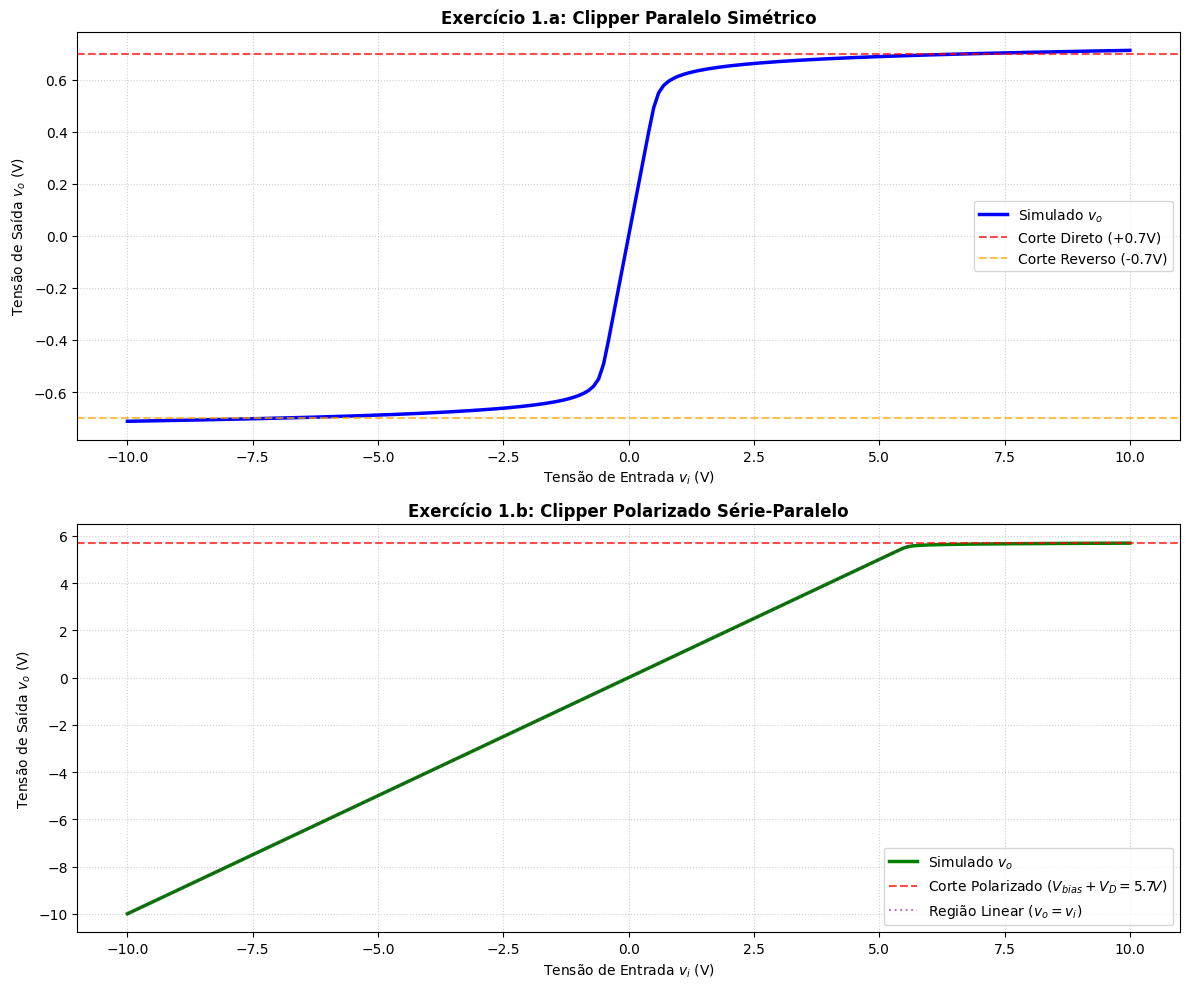

In [81]:
# Criando a área de plotagem para dois gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- GRÁFICO CIRCUITO A ---
# Nota: dependendo do seu netlist, 'analysis_a.v_in' e 'analysis_a.out' acessam os nós correspondentes
ax1.plot(analysis_a.v_in, analysis_a.out, color='blue', linewidth=2.5, label='Simulado $v_o$')
ax1.axhline(0.7, color='red', linestyle='--', alpha=0.7, label='Corte Direto (+0.7V)')
ax1.axhline(-0.7, color='orange', linestyle='--', alpha=0.7, label='Corte Reverso (-0.7V)')
ax1.set_title('Exercício 1.a: Clipper Paralelo Simétrico', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax1.set_ylabel('Tensão de Saída $v_o$ (V)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# --- GRÁFICO CIRCUITO B ---
ax2.plot(analysis_b.v_in, analysis_b.out, color='green', linewidth=2.5, label='Simulado $v_o$')
ax2.axhline(5.7, color='red', linestyle='--', alpha=0.7, label='Corte Polarizado ($V_{bias}+V_D = 5.7V$)')
ax2.plot([-10, 5.7], [-10, 5.7], color='purple', linestyle=':', alpha=0.5, label='Região Linear ($v_o = v_i$)')
ax2.set_title('Exercício 1.b: Clipper Polarizado Série-Paralelo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax2.set_ylabel('Tensão de Saída $v_o$ (V)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

---
# Exercício 2: Análise de Ponto de Operação DC (.OP)

Neste exercício, mudamos o foco de gráficos de variação (DC Sweep) para valores estáticos de tensões e correntes em nós específicos (Ponto Quiescente). 

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,6\text{ V}$ quando estão em condução direta.

---

#### Simulação e Resultados do Circuito 2.a

No circuito (a), temos dois diodos. O diodo da esquerda aponta para o terra (GND) e o da direita conecta-se ao nó de saída $V$ que está ligado a uma fonte negativa de $-10\text{ V}$ por meio de um resistor de $10\text{ k}\Omega$. 

Neste tipo de exercício, um bom ponto de partida é testar hipóteses para ter certeza que os diodos estão ligados ou não. Comece sempre supondo que ele não está e veja o que acontece. Se chegar em um absurdo, como uma tensão maior que $0.7V$ ao redor do diodo, um absurdo, quer dizer que ele está ligado.

Em seguida deve-se verificar se o enunciado pede ou não que se considere a resistencia do diodo, o que muda os valores encontrados. Feito isso, aplique o modelo e resolva as equações! Lembre-se que 

Para este exercício, deixei as equações montadas utilizando o modelo clássico de queda de tensão constante ($V_D = 0,7\text{ V}$). É fundamental destacar que as equações resolvidas dessa forma — sem incluir os termos logarítmicos ($\ln$) ou exponenciais ($\exp$) — são aproximações lineares por partes. Elas servem muito bem para estimativas de projeto rápidas, mas omitem a dependência real da corrente em relação à temperatura e aos parâmetros de fabricação do semicondutor.

O valor exato de operação de um diodo real só é alcançado resolvendo a equação transcendental de Shockley:

$$I_D = I_S \left( e^{\frac{V_D}{n V_T}} - 1 \right)$$

Como essa igualdade mistura termos lineares da malha com termos exponenciais do componente, ela não possui uma solução analítica fechada. O valor perfeitamente correto só é obtido por meio de solvers numéricos (como o algoritmo de Newton-Raphson integrado nos motores SPICE), que realizam sucessivas iterações até convergir para o ponto de operação exato.

Dito isso, vamos executar uma simulação do tipo **Operating Point (`.op()`)** para extrair as correntes e tensões exatas calculadas pelo simulador e compará-las com a nossa aproximação de malha.

Deixei duas figuras em `figuras/q1_a` e `figuras/q1_b` com uma resolução na mão para referencia. 

In [100]:
# 1. Carrega o Netlist do Circuito 2a
parser_a = SpiceParser(path='netlists/q2/circuit_a.net')
circuit_a = parser_a.build_circuit()

# 2. Executa a análise de ponto de operação (.OP)
simulator_a = circuit_a.simulator()
operating_point_a = simulator_a.operating_point()

# 3. Exibe os resultados calculados pelo simulador
# NOTA: Certifique-se de que os nomes dos nós ('v' para a tensão) e componentes ('D1' para o diodo) batem com o seu netlist
print("=== RESULTADOS SIMULADOS: CIRCUITO 2.a ===")

# Tensões dos nós
v_no_central = float(operating_point_a['no_central'][0]) * 1000
v_node = float(operating_point_a['v'][0]) * 1000

print(f"V(no_central) = {v_no_central:.3f} mV") 
print(f"V = {v_node:.3f} mV")

# Correntes através das fontes de teste de 0 V
v_no_central = float(operating_point_a['no_central'][0])
v_node = float(operating_point_a['v'][0])

id1 = -float(operating_point_a.branches['vprobe1'][0]) * 1000
id2 = -float(operating_point_a.branches['vprobe2'][0]) * 1000

print(f"I(D1) = {id1:.3f} mA")
print(f"I(D2) = {id2:.3f} mA")

# Corrente indicada no enunciado (diodo da esquerda)
print(f"Corrente Indicada I = {id1:.3f} mA")

=== RESULTADOS SIMULADOS: CIRCUITO 2.a ===
V(no_central) = 665.407 mV
V = -4.585 mV
I(D1) = -0.867 mA
I(D2) = -1.000 mA
Corrente Indicada I = -0.867 mA


#### Simulação e Resultados do Circuito 2.b

No circuito (b), o diodo $D$ está posicionado horizontalmente conectando dois ramos divisores de tensão tensionados por $10\text{ V}$ e $15\text{ V}$ respectivamente. Note que a seta da corrente $I$ aponta da direita para a esquerda (do nó de $15\text{ V}$ para o de $10\text{ V}$), o que coincide com a direção do anodo para o catodo do diodo. 

Vamos analisar a tensão diferencial $V$ nos terminais do diodo e a corrente $I$ que o atravessa.

In [101]:
# 1. Carrega o Netlist do Circuito 2b
parser_b = SpiceParser(path='netlists/q2/circuit_b.net')
circuit_b = parser_b.build_circuit()

# 2. Executa a análise .OP
simulator_b = circuit_b.simulator()
operating_point_b = simulator_b.operating_point()

print("=== RESULTADOS SIMULADOS: CIRCUITO 2.b ===")

# Tensão V (Diferencial nos terminais do diodo: V = V_anodo - V_catodo)
# Substitua 'no_direito' e 'no_esquerdo' pelos nomes reais dos nós gerados pelo seu LTspice
v_anodo = float(operating_point_b['no_direito'][0])
v_catodo = float(operating_point_b['no_esquerdo'][0])
v_diferencial = v_anodo - v_catodo

print(f"Tensão nos terminais do diodo (V) = {v_diferencial:.3f} V")

# Corrente I (Através do diodo horizontal)
i_horizontal = -float(operating_point_b.branches['vprobe_d'][0]) * 1000

print(f"Corrente Indicada I = {i_horizontal:.3f} mA")

=== RESULTADOS SIMULADOS: CIRCUITO 2.b ===
Tensão nos terminais do diodo (V) = 0.616 V
Corrente Indicada I = -0.188 mA


---
# Exercício 3: Gráfico entrada x saída 

Neste exercício, o foco volta aos gráficos de variação.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7\text{ V}$ quando estão em condução direta.

In [84]:
# 1. Carrega o arquivo de netlist exportado do LTspice
parser_a = SpiceParser(path='netlists/q3/circuit_a.net')
circuit_a = parser_a.build_circuit()

# 2. Configura o simulador interno do PySpice
simulator_a = circuit_a.simulator()

# 3. Executa a varredura DC na fonte de entrada (ajuste o nome 'Vinput' se necessário)
analysis_a = simulator_a.transient(step_time=0.1e-3, end_time=50e-3)

print("Simulação do Circuito A concluída com sucesso.")

Simulação do Circuito A concluída com sucesso.


In [85]:
# 1. Carrega o netlist do circuito limitador
parser_b = SpiceParser(path='netlists/q3/circuit_b.net')
circuit_b = parser_b.build_circuit()

# 2. Configura o simulador
simulator_b = circuit_b.simulator()

# 3. Executa a varredura DC
analysis_b = simulator_b.dc(Vi=slice(-10, 15, 0.05))

print("Simulação do Circuito 3.b concluída com sucesso.")

Simulação do Circuito 3.b concluída com sucesso.


#### Agora visualização: 

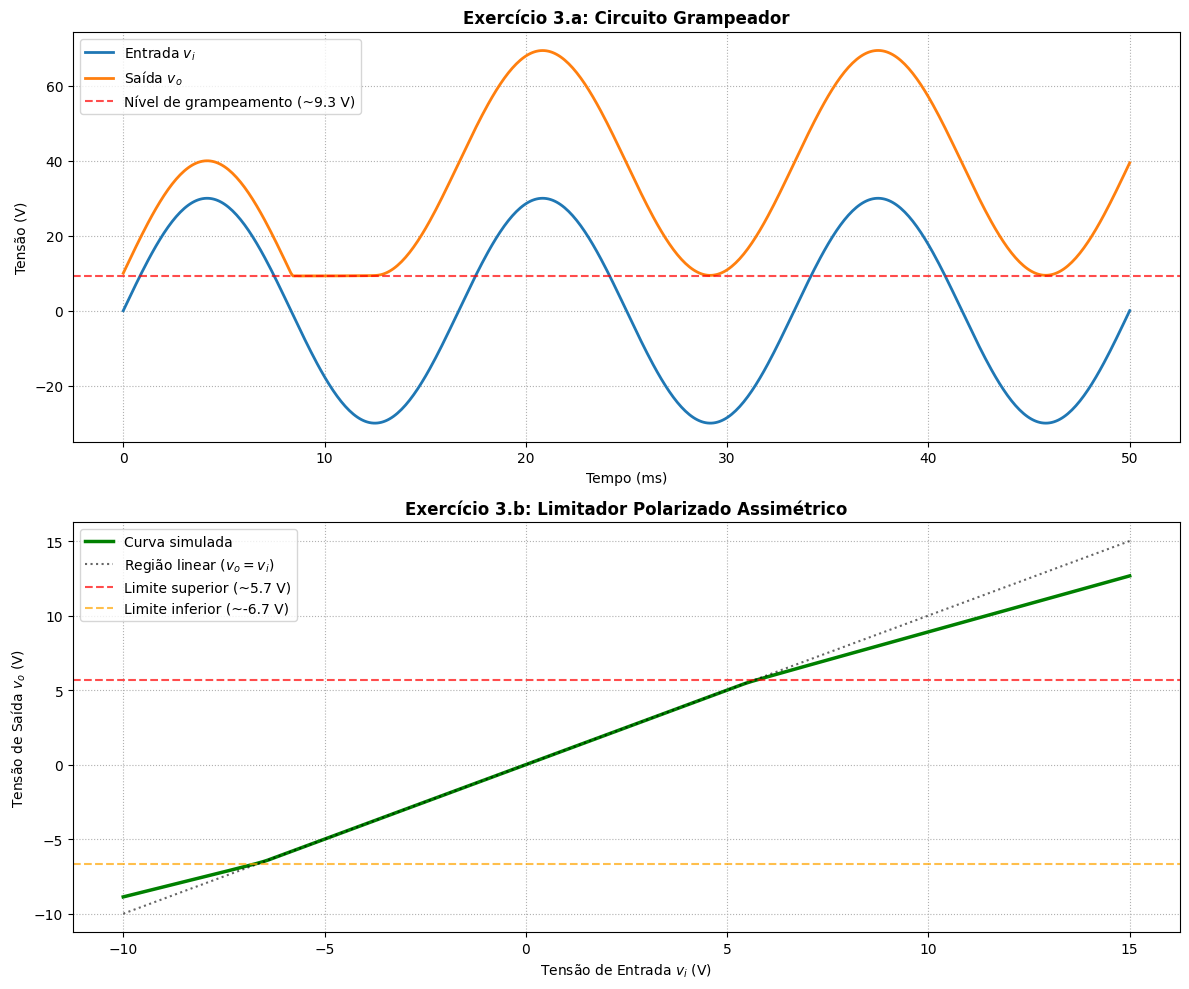

In [86]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10))
tempo_ms = analysis_a.time * 1000

ax1.plot(tempo_ms, analysis_a['vi'], linewidth=2, label='Entrada $v_i$')
ax1.plot(tempo_ms, analysis_a['vo'], linewidth=2, label='Saída $v_o$')
ax1.axhline(9.3, color='red', linestyle='--', alpha=0.7, label='Nível de grampeamento (~9.3 V)')
ax1.set_title('Exercício 3.a: Circuito Grampeador', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.grid(True, linestyle=':')
ax1.legend()

vin = analysis_b.sweep
vout = analysis_b['vo']
ax2.plot(vin, vout, color='green', linewidth=2.5, label='Curva simulada')
ax2.plot([-10, 15], [-10, 15], linestyle=':', color='black', alpha=0.6, label='Região linear ($v_o=v_i$)')
ax2.axhline(5.7, color='red', linestyle='--', alpha=0.7, label='Limite superior (~5.7 V)')
ax2.axhline(-6.7, color='orange', linestyle='--', alpha=0.7, label='Limite inferior (~-6.7 V)')
ax2.set_title('Exercício 3.b: Limitador Polarizado Assimétrico', fontsize=12, fontweight='bold')
ax2.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax2.set_ylabel('Tensão de Saída $v_o$ (V)')
ax2.grid(True, linestyle=':')
ax2.legend()

plt.tight_layout()
plt.show()

#### Observação:

**No exercício 3.a o capacitor não tem por onde descarregar. Testar com um resistor em série com a fonte!!**

---
# EXERCÍCIO 4: Retificador de Onda Completa de Precisão 

Neste exercício, considerar sempre a entrada senoidal.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7V$ quando estão em condução direta.

Primeiramente, analisaremos o circuito como montado na lista, aqui montado com $R = R_S = 10k\Omega$:

<p align="center">
    <img src="figuras/q4_1.png" width="800">
</p>

Se trata de um *primeiro estágio não linear* com diodos retificando a forma de onda $v_e$ e um *segundo estágio linear tipo somador inversor* com um dos ramos multiplicado por dois (se lembre do ganho do somador da lista I).

Pense nesse primeiro estágio como um inversor. Quando $v_e$ é positivo ele empurra corrente no nó inversor do primeiro AmpOp. Para manter o potencial desse nó em $0V (terra virtual)$, a saída do amplificador é forçada a ir para o lado negativo. 

Vamos entender o comportamento dinâmico desse primeiro estágio e onde mora o problema do circuito original da lista:

### Dinâmica de Operação dos Diodos

* **Semiciclo Positivo ($v_e > 0$):**
  * A entrada empurra corrente para o nó inversor. A saída bruta do AmpOp vai para o **negativo**, o que liga o diodo **D1** e corta o diodo **D2**.
  * Toda a corrente de entrada passa pelo resistor que polariza D1.
  * **O problema:** Para fazer **D1** conduzir, a saída do AmpOp precisa cair um adicional de **0,7V** abaixo da tensão do nó de realimentação.

* **Semiciclo Negativo ($v_e < 0$):**
  * A entrada puxa corrente do nó inversor. A saída do AmpOp é forçada a ir para o **positivo**, cortando **D1** e ligando **D2**.
  * Como **D2** fecha a malha diretamente sobre o nó inversor (**0V**), a saída do AmpOp fica cravada em **+0,7V** para manter o diodo ligado.

---

### O Ponto Crítico dessa montagem  

Como o diagrama colhe o sinal intermediário $v_I$ diretamente no pino de saída do AmpOp, nós não veremos uma meia-onda perfeita nessa medição. Veremos o operacional dando saltos abruptos de tensão toda vez que a entrada cruza o zero para conseguir vencer a barreira dos diodos. 

> **O que esperar da simulação abaixo:** O nó intermediário terá um degrau de $+0,7V$ no semiciclo negativo e sofrerá um deslocamento de $-0,7V$ no semiciclo positivo. Ao injetar essa onda deformada no segundo estágio, a saída final $v_O$ ficará completamente distorcida.

A seguir, vamos rodar a simulação transiente para medir a entrada $v_e$ em confronto direto com esse nó $v_I$ e visualizar essa distorção na prática.

Node name 'in' is a Python keyword


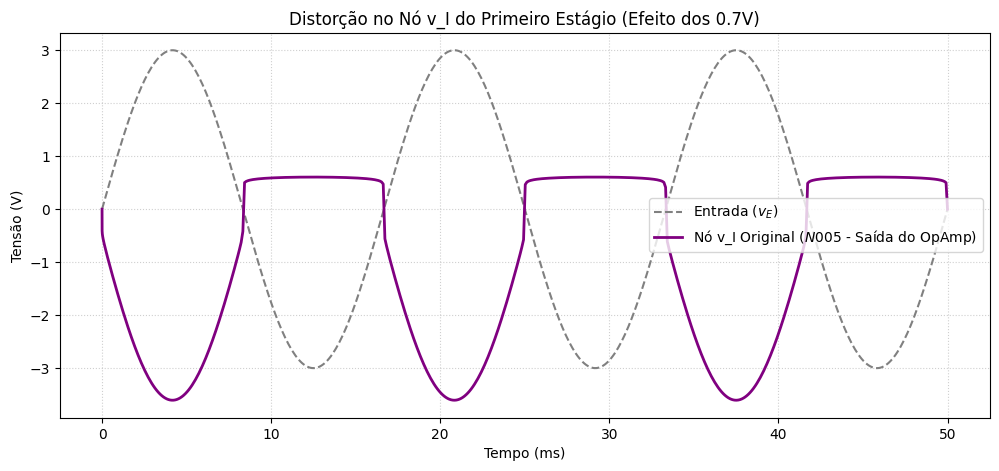

In [87]:
# Carrega e simula a netlist original
parser = SpiceParser(path='netlists/q4/circuit_a.net')
circuit = parser.build_circuit()
simulator = circuit.simulator()
analysis = simulator.transient(step_time=100e-6, end_time=50e-3)

# Extração dos nós (o PySpice converte os nomes dos nós para minúsculo)
t = analysis.time * 1000  # em ms
v_in = analysis['in']
v_I_errado = analysis['n005']
v_out_errado = analysis['n002']

# Plot do sinal intermediário zuado pelas quedas de 0.7V
plt.figure(figsize=(12, 5))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_I_errado, label='Nó v_I Original ($N005$ - Saída do OpAmp)', color='purple', linewidth=2)
#plt.plot(t, v_out_errado, label='Saída Final $v_O$ Distorcida', color='darkred', linewidth=2)
plt.title('Distorção no Nó v_I do Primeiro Estágio (Efeito dos 0.7V)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Simulação com a Correção do Nó de Captura
Para eliminar a distorção provocada pelo salto de $0,7\text{ V}$ dos diodos, o resistor `R4` do segundo estágio deve coletar o sinal do antes do diodo $D_1$:

<p align="center">
    <img src="figuras/q4_2.png" width="800">
</p>

Neste ponto, a malha de realimentação negativa do operacional absorve e anula a queda de tensão do diodo, entregando uma onda perfeitamente retificada de meia-onda para o somador do segundo estágio.

Node name 'in' is a Python keyword


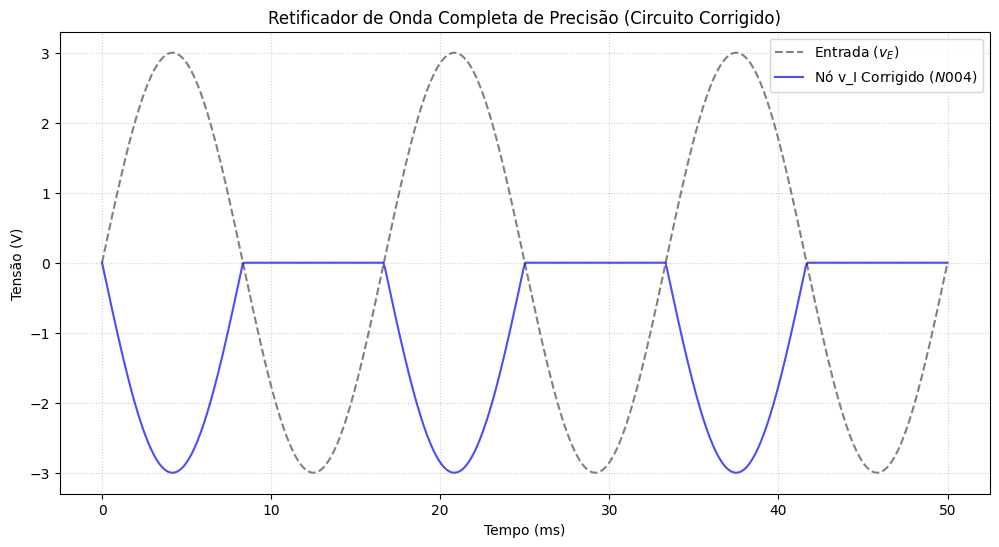

In [88]:
# Carrega e simula a netlist corrigida
parser = SpiceParser(path='netlists/q4/circuit_a_correto.net')
circuit = parser.build_circuit()
simulator = circuit.simulator()
analysis = simulator.transient(step_time=100e-6, end_time=50e-3)

v_I_corrigido = analysis['n004']
v_out_corrigido = analysis['n002']

# Plot Comparativo Final
plt.figure(figsize=(12, 6))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_I_corrigido, label='Nó v_I Corrigido ($N004$)', color='blue', alpha=0.7)
plt.title('Retificador de Onda Completa de Precisão (Circuito Corrigido)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### Demonstração Matemática

Após a correção, o primeiro estágio entrega uma meia-onda inversora ideal no nó **v_I**:

$$v_I = \begin{cases} -v_e, & \text{se } v_e > 0 \\ 0, & \text{se } v_e \le 0 \end{cases}$$

O segundo estágio é um somador inversor. Olhando para os resistores ($R_6 = 10\text{ k}\Omega$, $R_5 = 10\text{ k}\Omega$, $R_4 = 5\text{ k}\Omega$), a equação da saída **v_O** é:

$$v_O = - \left( \frac{10\text{ k}}{10\text{ k}} \cdot v_e + \frac{10\text{ k}}{5\text{ k}} \cdot v_I \right) = - (v_e + 2v_I)$$

### Substituindo os Semiciclos

* **Semiciclo Positivo ($v_e > 0 \rightarrow v_I = -v_e$):**
  $$v_O = - (v_e + 2(-v_e)) = - (v_e - 2v_e) = v_e$$

* **Semiciclo Negativo ($v_e < 0 \rightarrow v_I = 0$):**
  $$v_O = - (v_e + 2(0)) = -v_e$$

Portanto, em qualquer cenário a saída assume o valor absoluto da entrada:

$$v_O = |v_e|$$

A saída fica como segue.

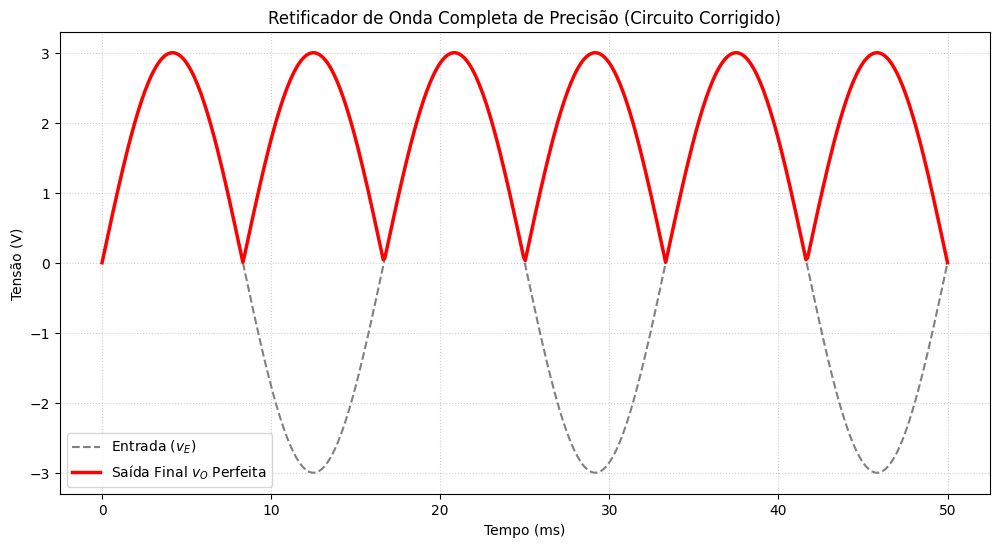

In [89]:
# Plot Comparativo Final
plt.figure(figsize=(12, 6))
plt.plot(t, v_in, label='Entrada ($v_E$)', color='gray', linestyle='--')
plt.plot(t, v_out_corrigido, label='Saída Final $v_O$ Perfeita', color='red', linewidth=2.5)
plt.title('Retificador de Onda Completa de Precisão (Circuito Corrigido)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

---
# EXERCÍCIO 5: Circuitos com Zener e Diodos

**Premissas:** Diodos em condução direta possuem $V_D = 0,7\text{ V}$. Zener em condução reversa (região Zener) possui $V_Z = 4,3\text{ V}$.

### Análise Teórica dos Gráficos $v_O \times v_i$:
* **Circuito 5a (Protetor de Barra / Clamping):** * Se $v_i > V_{DD} + 0,7\text{ V}$, o diodo $D_2$ conduz e trava a saída em $V_{DD} + 0,7\text{ V}$.
  * Se $v_i < -0,7\text{ V}$, o diodo $D_1$ conduz e trava a saída em $-0,7\text{ V}$.
* **Circuito 5b (Zeners em Série Opostos):** * Quando $v_i > 0$, $Z_1$ fica em inversa ($4,3\text{ V}$) e $Z_2$ em direta ($0,7\text{ V}$). A saída trava em $+5\text{ V}$.
  * Quando $v_i < 0$, $Z_1$ fica em direta ($0,7\text{ V}$) e $Z_2$ em inversa ($4,3\text{ V}$). A saída trava em $-5\text{ V}$.
* **Circuito 5c (Ponte Retificadora):** A saída $v_O$ sobre o resistor colhe a retificação de onda completa com duas quedas de diodo ($v_O = |v_i| - 1,4\text{ V}$).
* **Circuito 5e (Regulador Amperométrico Inversor):** O Zener $Z_1$ está na malha de realimentação invertida. 
  * Para $v_i > 0$, o AmpOp vai para o negativo, operando $Z_1$ em direta: $v_O = +0,7\text{ V}$.
  * Para $v_i < 0$, o AmpOp vai para o positivo, operando $Z_1$ em inversa (Zener): $v_O = -4,3\text{ V}$.

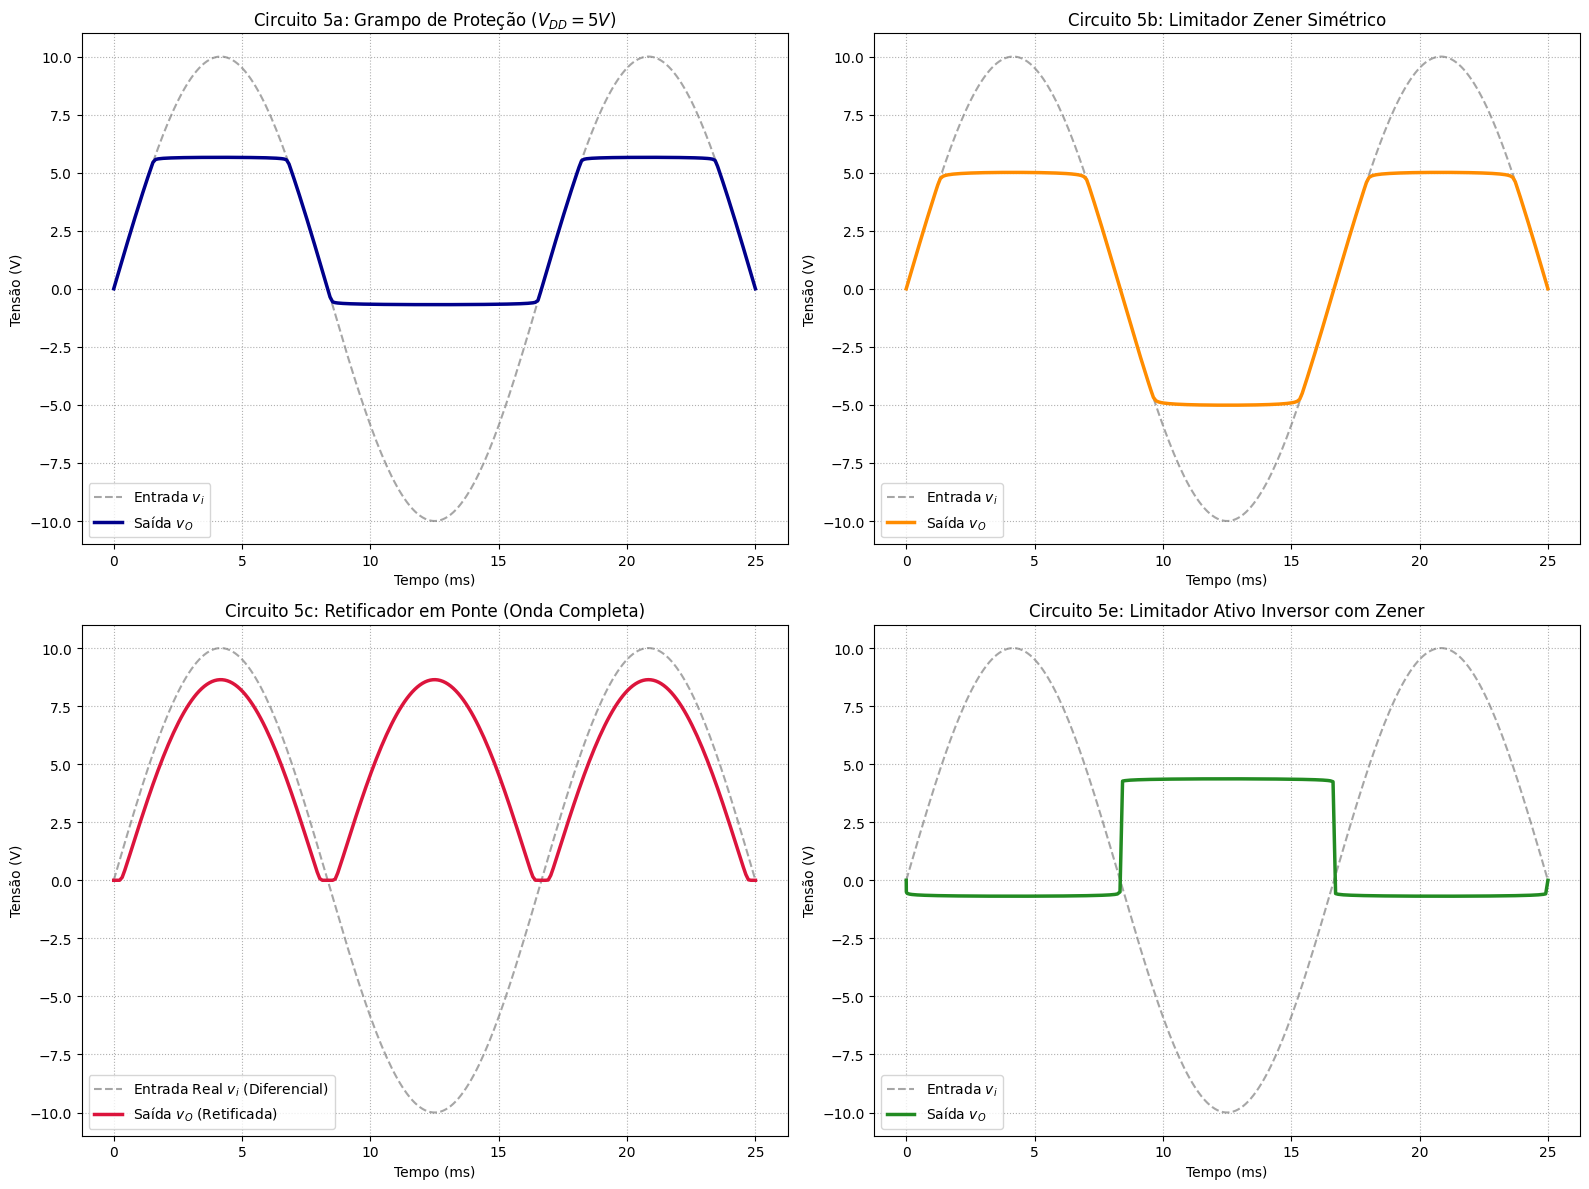

In [90]:
# --- NETLISTS DO EXERCÍCIO 5 ---

# Definindo constantes para os testes das fontes auxiliares
VDD = 5

# --- EXECUÇÃO DAS SIMULAÇÕES ---
analysis_5a = SpiceParser(path='netlists/q5/circuit_a.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5b = SpiceParser(path='netlists/q5/circuit_b.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5c = SpiceParser(path='netlists/q5/circuit_c.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)
analysis_5e = SpiceParser(path='netlists/q5/circuit_d.net').build_circuit().simulator().transient(step_time=100e-6, end_time=25e-3)

# --- 3. PLOTAGEM DOS GRÁFICOS CORRIGIDOS ---
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 5a - Grampo de Proteção
t_a = analysis_5a.time * 1000
axs[0, 0].plot(t_a, analysis_5a['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[0, 0].plot(t_a, analysis_5a['vo'], color='darkblue', linewidth=2.5, label='Saída $v_O$')
axs[0, 0].set_title('Circuito 5a: Grampo de Proteção ($V_{DD} = 5V$)')
axs[0, 0].set_xlabel('Tempo (ms)'); axs[0, 0].set_ylabel('Tensão (V)'); axs[0, 0].grid(True, linestyle=':'); axs[0, 0].legend()

# 5b - Limitador Zener Costas com Costas
t_b = analysis_5b.time * 1000
axs[0, 1].plot(t_b, analysis_5b['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[0, 1].plot(t_b, analysis_5b['vo'], color='darkorange', linewidth=2.5, label='Saída $v_O$')
axs[0, 1].set_title('Circuito 5b: Limitador Zener Simétrico')
axs[0, 1].set_xlabel('Tempo (ms)'); axs[0, 1].set_ylabel('Tensão (V)'); axs[0, 1].grid(True, linestyle=':'); axs[0, 1].legend()

# 5c - CORRIGIDO: ENTRADA DIFERENCIAL (vi - 2)
t_c = analysis_5c.time * 1000
v_in_real_ponte = analysis_5c['vi'] - analysis_5c['2'] # <--- A MÁGICA TÁ AQUI
axs[1, 0].plot(t_c, v_in_real_ponte, color='gray', linestyle='--', alpha=0.7, label='Entrada Real $v_i$ (Diferencial)')
axs[1, 0].plot(t_c, analysis_5c['vo'], color='crimson', linewidth=2.5, label='Saída $v_O$ (Retificada)')
axs[1, 0].set_title('Circuito 5c: Retificador em Ponte (Onda Completa)')
axs[1, 0].set_xlabel('Tempo (ms)'); axs[1, 0].set_ylabel('Tensão (V)'); axs[1, 0].grid(True, linestyle=':'); axs[1, 0].legend()

# 5e - AmpOp com Zener
t_e = analysis_5e.time * 1000
axs[1, 1].plot(t_e, analysis_5e['vi'], color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i$')
axs[1, 1].plot(t_e, analysis_5e['vo'], color='forestgreen', linewidth=2.5, label='Saída $v_O$')
axs[1, 1].set_title('Circuito 5e: Limitador Ativo Inversor com Zener')
axs[1, 1].set_xlabel('Tempo (ms)'); axs[1, 1].set_ylabel('Tensão (V)'); axs[1, 1].grid(True, linestyle=':'); axs[1, 1].legend()

plt.tight_layout()
plt.show()

---
# EXERCÍCIO 6: Proporcionalidade à Temperatura Absoluta 

A equação fundamental de Shockley que governa a tensão sobre um diodo polarizado diretamente é expressa por:
$$I_D = I_S \cdot \left( e^{\frac{V_D}{n \cdot V_T}} - 1 \right) \approx I_S \cdot e^{\frac{V_D}{n \cdot V_T}}$$

Isolando a queda de tensão elétrica direta $V_D$, obtemos:
$$V_D = n \cdot V_T \cdot \ln\left(\frac{I_D}{I_S}\right)$$

Onde $V_T$ é a **Tensão Térmica**, definida pela relação física:
$$V_T = \frac{k \cdot T}{q}$$
* $k$: Constante de Boltzmann
* $T$: Temperatura absoluta em Kelvin
* $q$: Carga elementar do elétron

### Aplicando ao Circuito da Figura 6

Dois diodos idênticos ($D_1$ e $D_2$) compartilham o mesmo processo de fabricação, o que significa que possuem a mesma corrente de saturação reversa ($I_{S1} = I_{S2} = I_S$) e o mesmo fator de idealidade ($n_1 = n_2 = n$).

Cada diodo é alimentado por uma fonte de corrente independente respectiva, logo:
* Para o diodo 1: $V_{D1} = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_S}\right)$
* Para o diodo 2: $V_{D2} = n \cdot V_T \cdot \ln\left(\frac{I_2}{I_S}\right)$

Analisando a diferença de potencial indicada para a saída $V_O$ entre os nós superiores dos diodos:
$$V_O = V_{D1} - V_{D2}$$

Substituindo as expressões logarítmicas:
$$V_O = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_S}\right) - n \cdot V_T \cdot \ln\left(\frac{I_2}{I_S}\right)$$

Utilizando a propriedade dos logaritmos para a divisão ($\ln(A) - \ln(B) = \ln(A/B)$):
$$V_O = n \cdot V_T \cdot \ln\left( \frac{I_1 / I_S}{I_2 / I_S} \right) = n \cdot V_T \cdot \ln\left(\frac{I_1}{I_2}\right)$$

Substituindo a definição da tensão térmica $V_T$:
$$V_O = \left[ \frac{n \cdot k \cdot \ln\left(\frac{I_1}{I_2}\right)}{q} \right] \cdot T$$

Como os termos dentro dos colchetes ($n, k, q$) são constantes físicas fixas e a razão entre as fontes de corrente ($I_1/I_2$) permanece constante ao longo do tempo, podemos agrupá-los em uma única constante global de ganho $K$:
$$K = \frac{n \cdot k \cdot \ln\left(\frac{I_1}{I_2}\right)}{q}$$

Resultando na equação linear direta:
$$V_O = K \cdot T$$

Da para simular a variação termica no SPICE com um step:

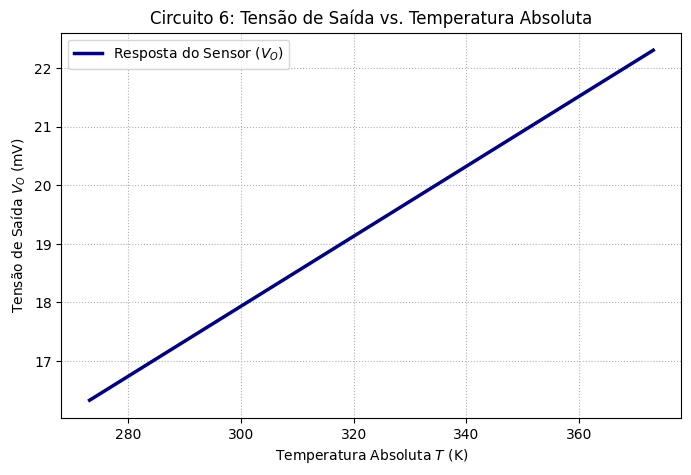

In [91]:
# Vamos calcular as saídas para diferentes temperaturas em Kelvin (0°C a 100°C)
temperaturas_celsius = np.linspace(0, 100, 50)
temperaturas_kelvin = temperaturas_celsius + 273.15

# Constantes físicas para validação teórica
k = 1.38e-23
q = 1.60e-19
I1, I2 = 2e-3, 1e-3
v_out_teorico = (k * temperaturas_kelvin / q) * np.log(I1 / I2)

# Plotagem da curva característica mostrando a proporcionalidade linear
plt.figure(figsize=(8, 5))
plt.plot(temperaturas_kelvin, v_out_teorico * 1000, color='darkblue', linewidth=2.5, label='Resposta do Sensor ($V_O$)')
plt.title('Circuito 6: Tensão de Saída vs. Temperatura Absoluta')
plt.xlabel('Temperatura Absoluta $T$ (K)')
plt.ylabel('Tensão de Saída $V_O$ (mV)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

### Contexto Histórico e o Desafio Prático nas Fontes de Corrente

Esse comportamento, embora seja perfeito para construir termômetros eletrônicos, foi um problema da engenharia de circuitos integrados nos primórdios dos amps.

Nos primeiros amplificadores transistorizados, os circuitos internos de polarização dependiam diretamente de diodos ou transistores operando como referências de corrente simples. Como a diferença de potencial e a condução desses componentes variam de forma previsível com a temperatura ($V_T$ sobe cerca de $2\text{ mV/°C}$), o ganho e, principalmente, a **tensão de offset** do amplificador começavam a "derivar" (mudar de valor) conforme o chip aquecia durante o funcionamento. 

Isso fazia com que um circuito calibrado para funcionar perfeitamente a $25\text{°C}$ apresentasse distorções severas ou saísse de operação ao atingir $60\text{°C}$.

###  Cuidado Necessário com Fontes e Espelhos de Corrente

Quando projetamos fontes ou espelhos de corrente baseados em bipolares, precisamos ficar extremamente atentos a dois fatores críticos:

1. **Thermal Matching:** Em um espelho de corrente convencional (como o Espelho de Widlar ou Wilson), se um transistor esquentar mais do que o outro devido à dissipação de potência, a sua tensão base-emissor ($V_{BE}$) cai. Isso força o transistor mais quente a puxar ainda mais corrente, gerando um efeito bola de neve conhecido como **Thermal Runaway**, que pode destruir o componente, ou simplesmente zoar o amp. Por isso, em circuitos integrados, esses transistores são fabricados colados um ao outro para garantir que fiquem exatamente na mesma temperatura.
2. **Correção por Bandgap:** Para resolver o problema de circuitos que precisam de uma referência estável que **não mude** com a temperatura, os projetistas criaram a **Referência Bandgap**. Ela funciona combinando uma tensão como a deste Exercício 6, que *sobe* com a temperatura, com uma tensão Proporcional à Temperatura Complementar, que *desce* com a temperatura. Ao somar as duas propriedades na proporção ex

---
# EXERCÍCIO 7: Uma fonte linear pratica

**7.a) Forma de Onda de $V_O$ (Tensão no Capacitor):**
A entrada é uma senoide com pico $V_p = 4\text{ V}$. A ponte de diodos impõe uma perda de duas quedas diretas ($2 \cdot 0,7\text{ V} = 1,4\text{ V}$). 
* O valor de pico que chega ao capacitor é:
  $$V_{O,\text{max}} = V_p - 2 \cdot V_D = 4 - 1,4 = 2,6\text{ V}$$
* Como o enunciado pede para considerar o *ripple* pequeno, a forma de onda de $V_O(t)$ é uma dente-de-serra suave. Ela sobe rapidamente até $2,6\text{ V}$ quando os diodos conduzem e recarrega o capacitor, segguida por uma descarga linear quase constante sobre o circuito regulador durante o resto do período.

**7.b) Forma de Onda de $V_{D1}$ (Tensão no Diodo $D_1$):**
* **Quando a ponte conduz no semiciclo positivo:** $D_1$ está em condução direta, logo sua tensão é cravada em sua queda interna:
  $$V_{D1} = +0,7\text{ V}$$
* **Quando a ponte inverte no semiciclo negativo:** $D_1$ fica cortado (bloqueado). A tensão reversa máxima que ele enxerga ocorre no pico negativo da entrada, onde ele precisa suportar a tensão do capacitor $V_O$ mais a amplitude da entrada rebatida:
  $$V_{D1,\text{min}} \approx -(V_{O,\text{max}} + V_p - V_D) \implies \text{Pivô de pico reverso próximo a }-5,9\text{ V}$$

**7.c) Estimativa do Ripple em $V_O$:**
A aproximação linear clássica para o *ripple* de pico a pico ($\Delta V_O$) em um retificador de onda completa é dada por:
$$\Delta V_O = \frac{I_{\text{carga}}}{2 \cdot f \cdot C}$$
Onde $f = 60\text{ Hz}$ (frequência da rede). 

Seguindo a sugestão do enunciado de usar a máxima tensão em $V_O$ ($V_{O,\text{max}} = 2,6\text{ V}$) para estimar a corrente máxima consumida pelo bloco regulador:
$$I_{\text{carga}} = \frac{V_{O,\text{max}} - V_s}{R}$$
Substituindo $I_{\text{carga}}$ na fórmula do ripple, obtemos a estimativa final:
$$\Delta V_O \approx \frac{2,6 - V_s}{2 \cdot 60 \cdot C \cdot R}$$

Na prática, costumo utilizar mais um estágio RC antes de um regulado (com zener ou seja lá o que for). Para isso basta olhar para cada par simplesmente como um filtro passa alta, o que vai reduzir o ripple de maniera proporcional a corrente que os estágios seguintes puxam.

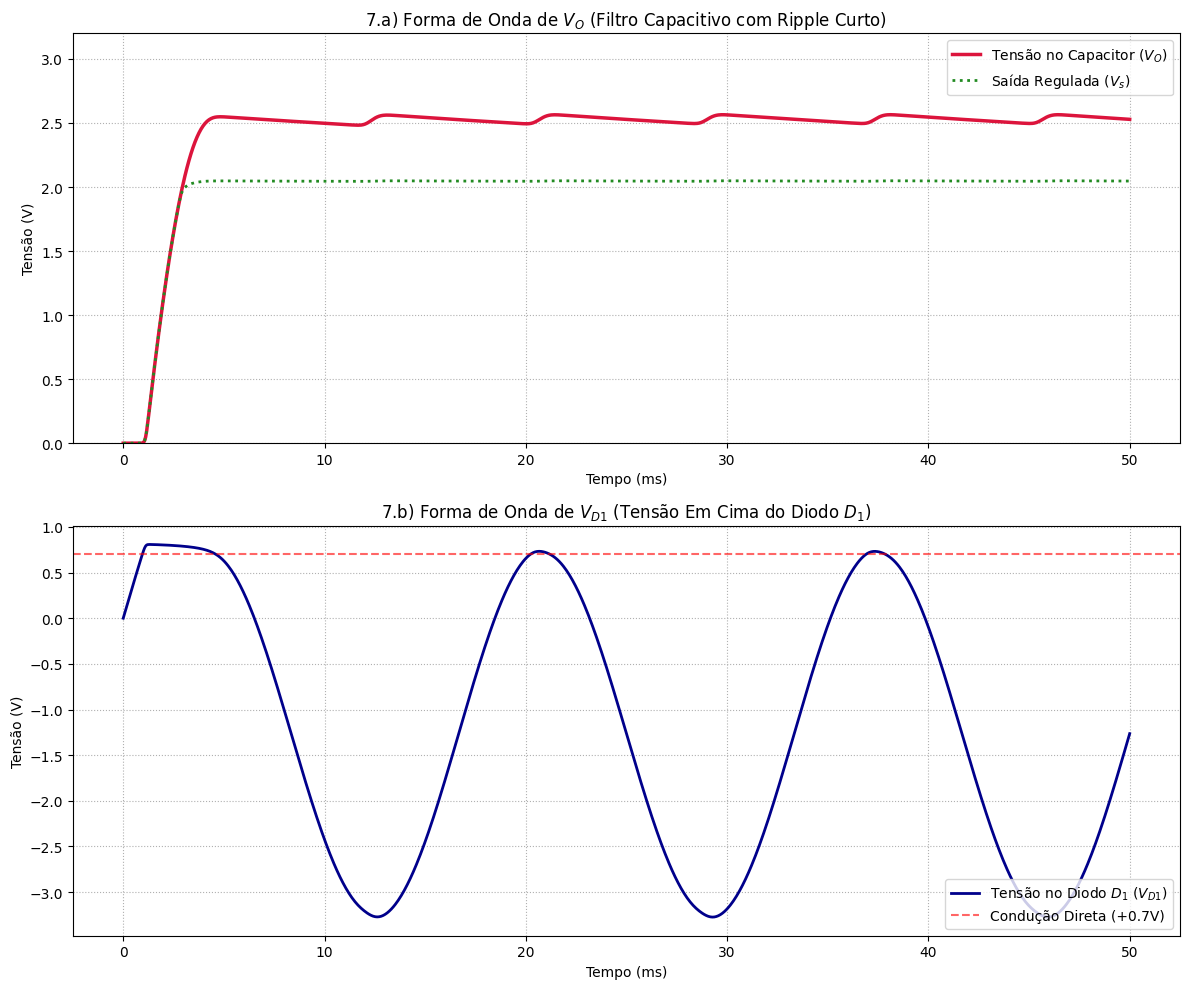

In [92]:
analysis = SpiceParser(path='netlists/q7/circuit.net').build_circuit().simulator().transient(step_time=50e-6, end_time=50e-3)

# Extração dos dados
t = analysis.time * 1000  # em ms
v_O = analysis['vo']      # Tensão no capacitor (7.a)
v_D1 = analysis['vi'] - analysis['vo']  # Tensão diferencial sobre D1 (7.b)
v_s = analysis['vs']      # Tensão regulada de saída

# --- PLOTAGEM DOS GRÁFICOS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 7.a: Forma de onda de Vo com ripple estável
ax1.plot(t, v_O, color='crimson', linewidth=2.5, label='Tensão no Capacitor ($V_O$)')
ax1.plot(t, v_s, color='forestgreen', linestyle=':', linewidth=2, label='Saída Regulada ($V_s$)')
ax1.set_title('7.a) Forma de Onda de $V_O$ (Filtro Capacitivo com Ripple Curto)')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.set_ylim(0, 3.2)
ax1.grid(True, linestyle=':')
ax1.legend(loc='upper right')

# Gráfico 7.b: Forma de onda de VD1
ax2.plot(t, v_D1, color='darkblue', linewidth=2, label='Tensão no Diodo $D_1$ ($V_{D1}$)')
ax2.axhline(0.7, color='red', linestyle='--', alpha=0.6, label='Condução Direta (+0.7V)')
ax2.set_title('7.b) Forma de Onda de $V_{D1}$ (Tensão Em Cima do Diodo $D_1$)')
ax2.set_xlabel('Tempo (ms)')
ax2.set_ylabel('Tensão (V)')
ax2.grid(True, linestyle=':')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
# EXERCÍCIO 8: Retificador de Precisão com regulador Zener

O circuito proposto originalmente apresenta uma **incompatibilidade de design** entre o bloco de retificação de precisão e o bloco de regulação. A saída do segundo amplificador operacional está conectada diretamente ao capacitor $C$. 

Como um AmpOp ideal possui impedância de saída nula ($R_{\text{out}} = 0$), ele impõe sua tensão de saída com capacidade de corrente infinita. Isso força o capacitor a carregar e descarregar instantaneamente, acompanhando perfeitamente a onda senoidal retificada ($v_O = |v_e|$) e eliminando qualquer efeito de filtragem dente-de-serra. 

Para sanar essa falha e viabilizar a análise clássica de *ripple*, **vou propor a inserção de um diodo de isolamento ($D_{\text{iso}}$)** entre a saída do segundo AmpOp e o capacitor de filtro.

**8.a) Forma de Onda do Nó Intermediário $v_I$:**

Como mostrado na 7, as quedas dos diodos $D_1$ e $D_2$ são perfeitamente compensadas pela topologia ativa. Assim, a resposta matemática exata no nó de medição $v_I$ é preservada:

* **Semiciclo Positivo ($v_e > 0$):** O diodo $D_1$ conduz, fechando a malha de realimentação invertida:
  $$v_I = -v_e = -A\sin(\omega t)$$
* **Semiciclo Negativo ($v_e < 0$):** O diodo $D_2$ conduz e estabiliza o AmpOp, deixando o nó $v_I$ completamente isolado e sem corrente externa:
  $$v_I = 0\text{ V}$$

A curva resultante em $v_I$ é uma **meia-onda inversora pura**, alcançando um pico mínimo de $-A$.

**8.b) Forma de Onda de $v_O$ (Tensão no Capacitor com Diodo de Isolamento):**

Com a adição do diodo de isolamento ($D_{\text{iso}}$) logo após o somador, o circuito passa a operar como um detector de envoltória de precisão:

* **Fase de Carga:** Quando a saída do somador inversor cresce e supera a tensão armazenada no capacitor, o diodo $D_{\text{iso}}$ liga. Sendo um circuito de precisão, o AmpOp fornece a corrente necessária para carregar o capacitor até o valor de pico integral da entrada, compensando qualquer queda de diodo:
  $$V_{O,\text{max}} = A$$
* **Fase de Descarga (Isolamento):** No momento em que a senoide retificada começa a decrescer, o AmpOp reduz sua saída rapidamente. Como o capacitor tenta manter sua tensão, o diodo $D_{\text{iso}}$ fica polarizado inversamente e **corta**. 
* **O Efeito Dente-de-Serra:** Com o AmpOp isolado, o capacitor $C$ é forçado a se descarregar de forma linear e lenta através do resistor limitador $R$ em direção ao diodo Zener. Como o *ripple* na saída é pequeno, a forma de onda resultante em $v_O$ estabiliza-se como o formato **dente-de-serra contínuo clássico**, operando na frequência de $2f = 120\text{ Hz}$.

**8.c) Estimativa do Ripple em $v_O$:**
Uma vez garantido o isolamento por meio do diodo $D_{\text{iso}}$, a taxa de descarga do capacitor passa a depender unicamente da corrente média exigida pelo bloco regulador/carga. A aproximação linear para o *ripple* de pico a pico ($\Delta v_O$) em um retificador de onda completa volta a ser válida:
$$\Delta v_O = \frac{I_{\text{carga}}}{2 \cdot f \cdot C}$$

Seguindo a diretriz de utilizar a máxima tensão de pico disponível no capacitor ($V_{O,\text{max}} = 3,7$) para estimar o pior cenário de consumo de corrente pelo regulador Zener:
$$I_{\text{carga}} = \frac{V_{O,\text{max}} -V_{Z0}}{R}$$

Substituindo essa corrente de descarga na equação do filtro capacitivo, obtemos a estimativa analítica rigorosa para a ondulação:
$$\Delta v_O \approx \frac{3,7 - V_{Z0}}{2 \cdot 60 \cdot C \cdot R}$$

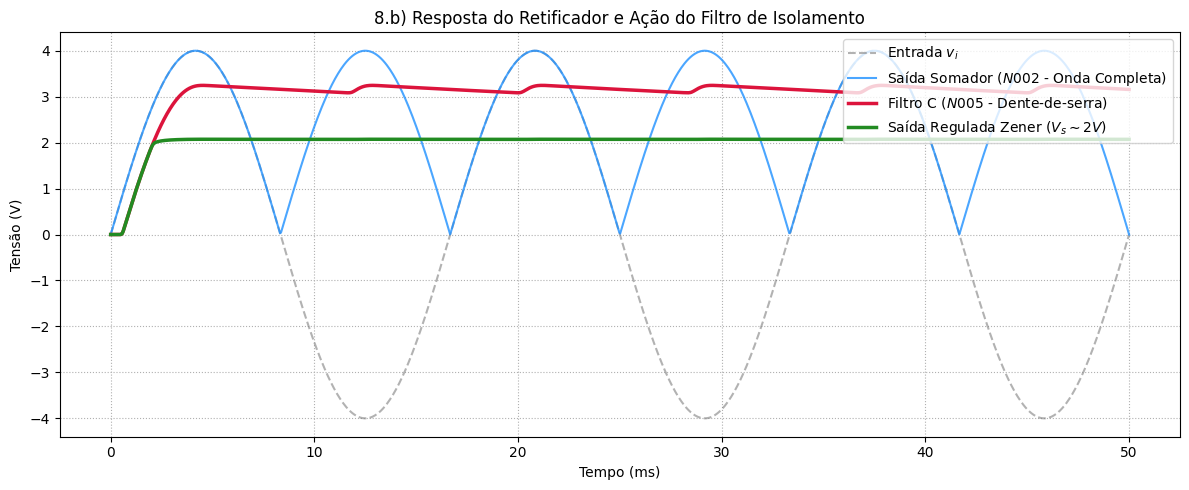

In [93]:
analysis = SpiceParser(path='netlists/q8/circuit.net').build_circuit().simulator().transient(step_time=50e-6, end_time=50e-3)

# Extraindo os dados dos vetores gerados pelo Ngspice
t = analysis.time * 1000  # ms
v_input = analysis['v_in']
v_op2 = analysis['n002']
v_cap = analysis['n005']
v_zener = analysis['n006']

# --- PLOTAGEM DOS GRÁFICOS ---
plt.figure(figsize=(12, 5))

# Subplot 1: Dinâmica de filtragem
plt.plot(t, v_input, color='gray', linestyle='--', alpha=0.6, label='Entrada $v_i$')
plt.plot(t, v_op2, color='dodgerblue', alpha=0.8, label='Saída Somador ($N002$ - Onda Completa)')
plt.plot(t, v_cap, color='crimson', linewidth=2.5, label='Filtro C ($N005$ - Dente-de-serra)')
plt.plot(t, v_zener, color='forestgreen', linewidth=2.5, label='Saída Regulada Zener ($V_s \sim 2V$)')
plt.title('8.b) Resposta do Retificador e Ação do Filtro de Isolamento')
plt.xlabel('Tempo (ms)'); plt.ylabel('Tensão (V)')
plt.grid(True, linestyle=':')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
# EXERCÍCIO 4: Retificador de Onda Completa  

Neste exercício, considerar sempre a entrada senoidal.

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7V$ quando estão em condução direta, e que sejam conhecidas a resistencia e a tensão $V_{z0}$ do diodo Zener.

O SPICE nos permite criar transformadores com o coeficiente de acoplamento entre indutores $k$:

<p align="center">
    <img src="figuras/q9.png" width="800">
</p>

Se trata de um circuito de fonte usando retificador de onda completa. O circuito é prático e pode ser usado desde que tenhamos um transformador de força com Center Tap (CT). 

---
### Resolução Analítica (Exercício 9)

**9.a) Identificação dos Blocos da Fonte de Tensão:**

* **Retificador:** Formado pelo transformador com CT de relação $2:1$ combinando os diodos $D_1$ e $D_2$. Ele realiza a retificação de onda completa.

* **Filtro:** O capacitor $C$ conectado em paralelo após os diodos, responsável por suavizar a tensão e transformá-la em uma tensão contínua com ondulação ($V_r$).

* **Regulador:** O conjunto do resistor limitador $R$ em série com o diodo Zener em paralelo com a carga. Ele mantém a tensão de saída $V_o$ estável próxima a $V_{Z0}$ mesmo com variações na carga ($I_L$).

**9.b) Formas de Onda em $V_r$ e $V_{D1}$:**

* **Tensão no Capacitor ($V_r$):** A tensão de entrada no primário tem pico de $20\text{ V}$. Devido à relação de transformação de $2:1$ para cada metade do secundário, as amplitudes senoidais de $V_1$ e $V_2$ possuem pico de:
  $$V_{\text{sec, pico}} = \frac{20}{2} = 10\text{ V}$$
  Descontando a queda de um único diodo por semiciclo ($V_D = 0,7\text{ V}$), o valor máximo atingido pelo capacitor é:
  $$V_{r,\text{max}} = 10 - 0,7 = 9,3\text{ V}$$
  A forma de onda em $V_r$ assume o formato dente-de-serra clássico flutuando logo abaixo de $9,3\text{ V}$.
* **Tensão no Diodo $D_1$ ($V_{D1}$):** Quando $D_1$ conduz, a sua tensão é cravada em $+0,7\text{ V}$. Quando $D_2$ conduz, $D_1$ fica bloqueado e experimenta no pior caso a soma da tensão do capacitor com o pico invertido da sua metade do secundário:
  $$V_{D1,\text{min}} \approx -(V_{r,\text{max}} + V_{\text{sec, pico}}) = -(9,3 + 10) = -19,3\text{ V}$$

**9.c) Estimativa do Ripple em $V_r$:**
A corrente que descarrega o capacitor passa pelo resistor $R$. Adotando a tensão máxima no capacitor ($V_{r,\text{max}} = 9,3\text{ V}$) e substituindo a tensão nominal do Zener por $V_{Z0} = 6,3\text{ V}$, a corrente de descarga estimada é:
$$I_{\text{descarga}} = \frac{9,3 - 6,3}{R} = \frac{3}{R}$$

Substituindo essa corrente na fórmula clássica do ripple para retificação de onda completa ($2f = 120\text{ Hz}$), obtemos a expressão numérica em função de $C$ e $R$:
$$\Delta V_r \approx \frac{3}{2 \cdot f \cdot C \cdot R} = \frac{3}{120 \cdot C \cdot R}$$


**9.d) Estimativa do Ripple em $V_o$ considerando $I_L = 0\text{ A}$:**
Quando a saída está em aberto ($I_L = 0\text{ A}$), o diodo Zener está operando na sua região de regulação com uma tensão de $6,3\text{ V}$. Para a componente alternada (o ripple), o capacitor atua como a fonte do sinal de ondulação, e a resistência dinâmica $r_Z$ do Zener forma um divisor de tensão com o resistor série $R$. A atenuação do ripple na saída é dada por:
$$\Delta V_o = \Delta V_r \cdot \left( \frac{r_Z}{R + r_Z} \right)$$

**9.e) Determinação do Valor Máximo Permitido para $R$:**
Para garantir que o Zener mantenha a regulação em $V_o = 6,3\text{ V}$ sob as piores condições possíveis, analisamos o circuito quando a entrada atinge o valor mínimo devido à ondulação e a carga drena a corrente máxima ($I_{L\text{Max}}$):

1. Determinamos a tensão mínima no capacitor utilizando o ripple estipulado de $0,2\text{ V}_{\text{PP}}$:
   $$V_{r,\text{min}} = V_{r,\text{max}} - \Delta V_r = 9,3 - 0,2 = 9,1\text{ V}$$

2. Pela lei dos nós no ponto de saída, a corrente que passa por $R$ deve suprir a carga e manter o Zener minimamente ativo ($I_{Z\text{Min}}$):
   $$I_R = I_{Z\text{Min}} + I_{L\text{Max}}$$

3. Substituindo os valores na lei de Ohm sobre o resistor $R$, definimos o limite superior para o seu dimensionamento:
   $$R_{\text{max}} = \frac{V_{r,\text{min}} - V_{Z0}}{I_{Z\text{Min}} + I_{L\text{Max}}} = \frac{9,1 - 6,3}{I_{Z\text{Min}} + I_{L\text{Max}}} = \frac{2,8}{I_{Z\text{Min}} + I_{L\text{Max}}}$$

**Ao se considerar a resistencia do diodo, a tensão nele deve ser acrescida da tensão decorrente da corrente de polarização passando por essa resistencia!**

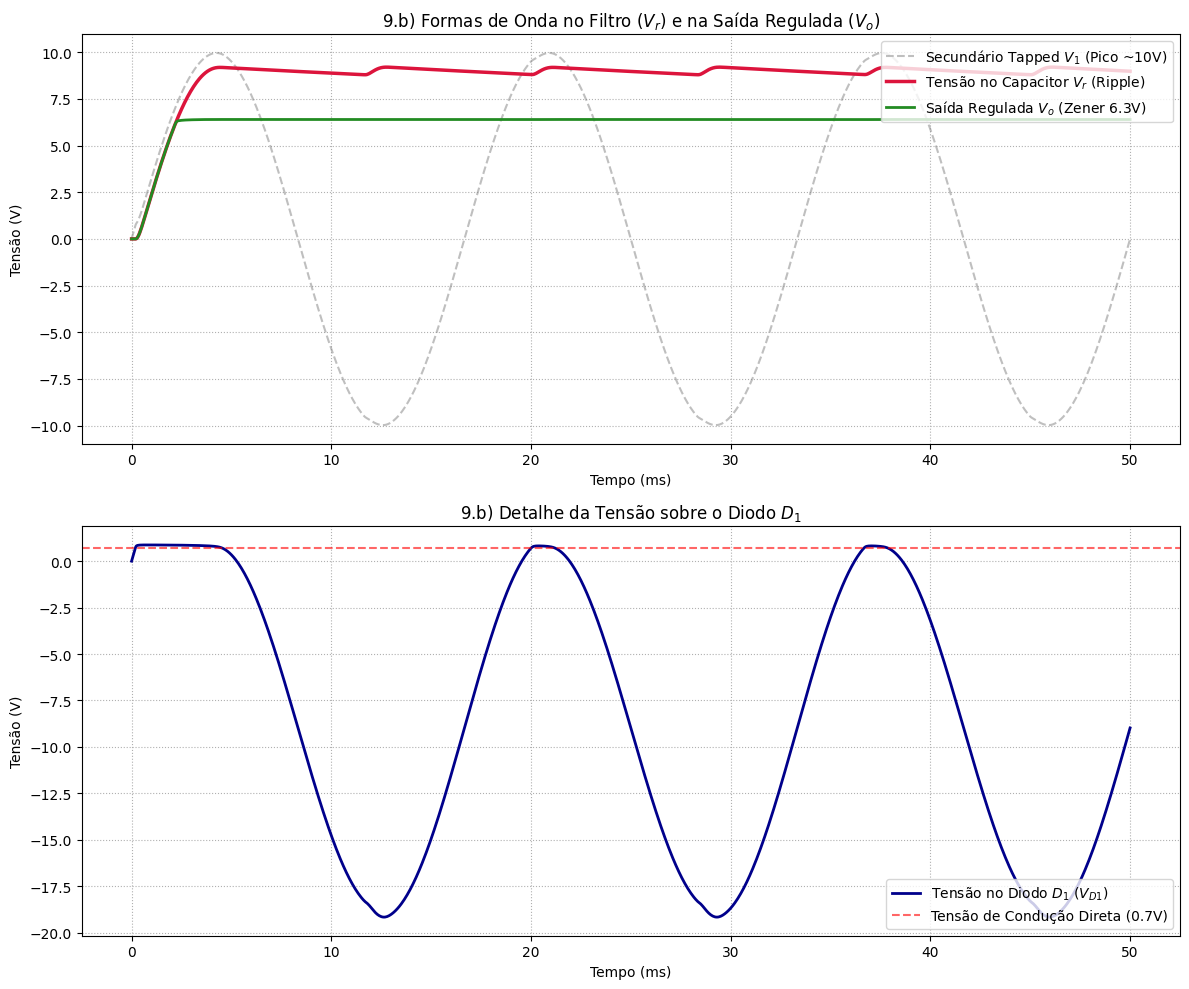

In [94]:
analysis = SpiceParser(path='netlists/q9/circuit.net').build_circuit().simulator().transient(step_time=50e-6, end_time=50e-3)

# Extração dos dados dos nós (Ngspice normaliza nomes em minúsculas)
t = analysis.time * 1000       # Tempo em ms
v_sec1 = analysis['n001']      # Tensão em uma das pernas do secundário
v_vr = analysis['n002']        # Tensão no capacitor (Vr com ripple)
v_vo = analysis['n003']        # Tensão na carga / Saída regulada pelo Zener (Vo)
v_d1 = analysis['n001'] - analysis['n002']  # Tensão diferencial sobre D1

# --- GRÁFICOS DO EXERCÍCIO 9 ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Subplot 1: Análise de Filtragem e Regulação de Saída (Vr e Vo)
ax1.plot(t, v_sec1, color='gray', linestyle='--', alpha=0.5, label='Secundário Tapped $V_1$ (Pico ~10V)')
ax1.plot(t, v_vr, color='crimson', linewidth=2.5, label='Tensão no Capacitor $V_r$ (Ripple)')
ax1.plot(t, v_vo, color='forestgreen', linewidth=2, label='Saída Regulada $V_o$ (Zener 6.3V)')
ax1.set_title('9.b) Formas de Onda no Filtro ($V_r$) e na Saída Regulada ($V_o$)')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.grid(True, linestyle=':')
ax1.legend(loc='upper right')

# Subplot 2: Tensão sobre o diodo D1 (Condução vs Bloqueio Reverso)
ax2.plot(t, v_d1, color='darkblue', linewidth=2, label='Tensão no Diodo $D_1$ ($V_{D1}$)')
ax2.axhline(0.7, color='red', linestyle='--', alpha=0.6, label='Tensão de Condução Direta (0.7V)')
ax2.set_title('9.b) Detalhe da Tensão sobre o Diodo $D_1$')
ax2.set_xlabel('Tempo (ms)')
ax2.set_ylabel('Tensão (V)')
ax2.grid(True, linestyle=':')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

---
# EXERCÍCIO 10: Inversor com clip zener  

A letra a) já foi respondida. 

**Premissa Teórica:** Considere que os diodos possuem uma queda de tensão constante de $V_D = 0,7V$ quando estão em condução direta, e que a tensão reversa no zener seja $V_{z0} = 4,3V$.

---
### Resolução Analítica (Exercício 10.b)

O circuito consiste em um amplificador inversor clássico em que a malha de realimentação possui um resistor $R$ em paralelo com um diodo Zener $Z_1$. Devido ao curto-circuito virtual do AmpOp ideal, o nó inversor ($-$) está mantido em $0\text{ V}$ (potencial de terra virtual). 

A corrente de entrada é ditada por:
$$I_{in} = \frac{v_i - 0}{R} = \frac{v_i}{R}$$

Essa corrente é forçada a passar pela malha de realimentação para alcançar a saída $V_0$. Vamos analisar o comportamento dependendo da polaridade de $v_i$:

#### 1. Região Linear (Zener Cortado)
Enquanto a tensão de saída $V_0$ não atingir os limiares de condução do Zener, o componente $Z_1$ se comporta como um circuito aberto. Toda a corrente $I_{in}$ flui exclusivamente pelo resistor de realimentação $R$.
A relação de saída é a de um inversor clássico com ganho unitário (pois os dois resistores valem $R$):
$$V_0 = -\left(\frac{R}{R}\right) \cdot v_i = -v_i$$

Esta região se mantém ativa contanto que a diferença de potencial sobre o Zener não provoque sua condução direta ou reversa.

#### 2. Semiciclo de Entrada Positivo ($v_i > 0$)
Quando $v_i$ aumenta positivamente, a corrente entra no nó inversor, forçando a saída $V_0$ a se deslocar para níveis negativos ($V_0 < 0$).
* Olhando a orientação do Zener $Z_1$ no diagrama, o seu anodo está conectado ao nó inversor ($0\text{ V}$) e o catodo (com a barra ondulada) está conectado à saída $V_0$.
* Com $V_0 < 0$, o catodo fica em um potencial menor que o anodo. Isso significa que o Zener fica **polarizado diretamente** (conduzindo como um diodo normal).
* O Zener grampeia a tensão entre os seus terminais na sua queda direta de $0,7\text{ V}$:
  $$V_{\text{anodo}} - V_{\text{catodo}} = 0,7\text{ V} \implies 0 - V_0 = 0,7\text{ V} \implies V_0 = -0,7\text{ V}$$
* **Ponto de transição:** O circuito sai da reta linear ($V_0 = -v_i$) e satura em $-0,7\text{ V}$ no instante em que $v_i \ge 0,7\text{ V}$.

#### 3. Semiciclo de Entrada Negativo ($v_i < 0$)
Quando $v_i$ diminui negativamente, a corrente é puxada do nó inversor, forçando a saída $V_0$ a subir para valores positivos ($V_0 > 0$).
* Com $V_0 > 0$, o catodo fica em um potencial maior que o anodo ($0\text{ V}$). Isso coloca o Zener sob **polarização reversa**.
* Conforme $v_i$ fica mais negativo, $V_0$ tenta subir linearmente até atingir a tensão de ruptura Zener ($V_Z = 4,3\text{ V}$).
* Uma vez atingido esse valor, o Zener entra em condução reversa e mantém a diferença de potencial travada:
  $$V_{\text{catodo}} - V_{\text{anodo}} = 4,3\text{ V} \implies V_0 - 0 = 4,3\text{ V} \implies V_0 = +4,3\text{ V}$$
* **Ponto de transição:** O circuito sai da reta linear ($V_0 = -v_i$) e satura em $+4,3\text{ V}$ no instante em que $v_i \le -4,3\text{ V}$.

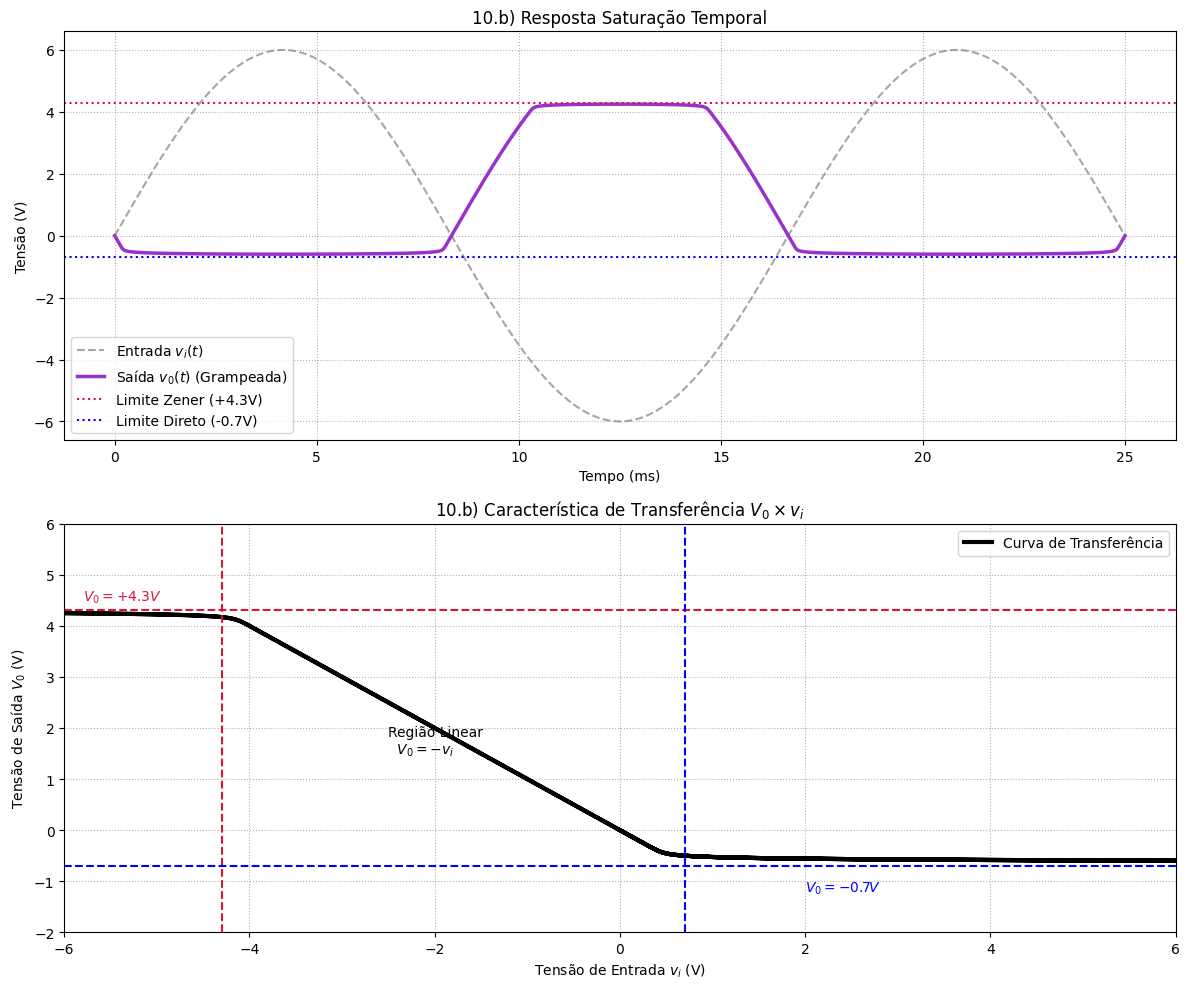

In [95]:
analysis = SpiceParser(path='netlists/q10/circuit.net').build_circuit().simulator().transient(step_time=20e-6, end_time=25e-3)

# Extraindo os vetores de dados
t = analysis.time * 1000
v_input = np.array(analysis['vi'])
v_output = np.array(analysis['vo'])

# --- GERAÇÃO DOS PLOTS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico esquerdo: Sinais no domínio do tempo
ax1.plot(t, v_input, color='gray', linestyle='--', alpha=0.7, label='Entrada $v_i(t)$')
ax1.plot(t, v_output, color='darkorchid', linewidth=2.5, label='Saída $v_0(t)$ (Grampeada)')
ax1.axhline(4.3, color='crimson', linestyle=':', label='Limite Zener (+4.3V)')
ax1.axhline(-0.7, color='blue', linestyle=':', label='Limite Direto (-0.7V)')
ax1.set_title('10.b) Resposta Saturação Temporal')
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('Tensão (V)')
ax1.grid(True, linestyle=':')
ax1.legend(loc='lower left')

# Gráfico direito: Curva de transferência característica (V0 x Vi)
ax2.plot(v_input, v_output, color='black', linewidth=3, label='Curva de Transferência')
ax2.axvline(-4.3, color='crimson', linestyle='--')
ax2.axhline(4.3, color='crimson', linestyle='--')
ax2.axvline(0.7, color='blue', linestyle='--')
ax2.axhline(-0.7, color='blue', linestyle='--')

# Marcações de eixos e legenda textuais para enriquecer o relatório
ax2.text(-5.8, 4.5, '$V_0 = +4.3V$', color='crimson')
ax2.text(2.0, -1.2, '$V_0 = -0.7V$', color='blue')
ax2.text(-2.5, 1.5, 'Região Linear\n  $V_0 = -v_i$', color='black')

ax2.set_title('10.b) Característica de Transferência $V_0 \\times v_i$')
ax2.set_xlabel('Tensão de Entrada $v_i$ (V)')
ax2.set_ylabel('Tensão de Saída $V_0$ (V)')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-2, 6)
ax2.grid(True, linestyle=':')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
# EXERCÍCIO 11: Fonte com Full Bridge e regulador Zener   

**Dados do enunciado:**
* Tensão eficaz no secundário: $V_{\text{ef}} = 12\text{ V}$
* Frequência da rede: $f = 60\text{ Hz}$ (Retificador em ponte $\implies f_{\text{ripple}} = 2f = 120\text{ Hz}$)
* Queda de tensão nos diodos em condução: $V_D = 0,8\text{ V}$
* Resistor de carga: $R_L = 100\ \Omega$
* Ondulação máxima desejada: $\Delta V = 1,0\text{ V}_{\text{PP}}$

---

### Resolução Analítica (Exercício 11)

**11.a) Determinação do Valor do Capacitor ($C$):**

1. **Cálculo da Tensão de Pico no Secundário ($V_p$):**
   $$V_p = V_{\text{ef}} \cdot \sqrt{2} = 12 \cdot \sqrt{2} \approx 16,97\text{ V}$$

2. **Cálculo da Tensão Máxima no Capacitor ($V_{C,\text{max}}$):**
   Em um retificador em ponte, a corrente sempre atravessa dois diodos em série a cada semiciclo. Portanto, subtraímos duas quedas de diodo:
   $$V_{C,\text{max}} = V_p - 2V_D = 16,97 - 2(0,8) = 15,37\text{ V}$$

3. **Estimativa da Corrente Máxima na Carga ($I_L$):**
   Seguindo a recomendação padrão de utilizar a tensão de pico para superdimensionar a corrente de descarga no pior cenário:
   $$I_L = \frac{V_{C,\text{max}}}{R_L} = \frac{15,37}{100} = 0,1537\text{ A} \implies 153,7\text{ mA}$$

4. **Cálculo da Capacitância ($C$):**
   Utilizando a fórmula linearizada do ripple para retificadores de onda completa:
   $$\Delta V = \frac{I_L}{2 \cdot f \cdot C} \implies C = \frac{I_L}{2 \cdot f \cdot \Delta V}$$
   
   Substituindo os valores numéricos:
   $$C = \frac{0,1537}{2 \cdot 60 \cdot 1,0} = \frac{0,1537}{120} \approx 1,281 \times 10^{-3}\text{ F} \approx 1281\ \mu\text{F}$$

*Valor comercial:* **$1500\ \mu\text{F}$** (sempre se joga pra cima!).

**11.b) Tensão Reversa Máxima nos Diodos (PIV):**

Em uma configuração de retificador em ponte com filtro capacitivo, quando um par de diodos está cortado, a tensão reversa máxima que se aplica sobre cada um deles ocorre no pico da senoide de entrada. 

O diodo cortado fica submetido à tensão de pico do secundário ($V_p$) menos a queda do diodo vizinho que está conduzindo, o que equivale de forma idealizada à própria tensão contida no capacitor:
$$\text{PIV} = V_p - V_D \approx V_{C,\text{max}} + V_D$$
$$\text{PIV} = 16,97 - 0,8 = 16,17\text{ V}$$

Dessa forma, cada diodo deve suportar uma tensão reversa de pico de pelo menos **$16,17\text{ V}$**.

O circuito fica como na figura a seguir. Usei um trafo com o mesmo k da questão anterior com relação de tensão 10:1 (120V no primário e 12V no secundário).

<p align="center">
    <img src="figuras/q11.png" width="800">
</p>

--- DADOS EXTRAÍDOS DA SIMULAÇÃO ---
Tensão Máxima na Carga (V_max): 15.46 V
Tensão Mínima na Carga (V_min): 14.73 V
Ondulação de Pico a Pico (Ripple): 0.73 V


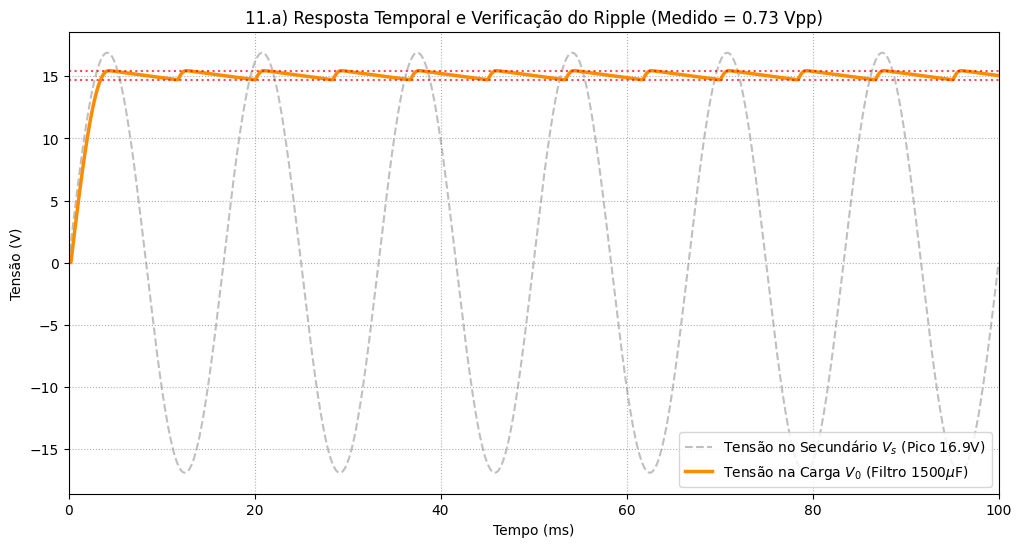

In [96]:
analysis = SpiceParser(path='netlists/q11/circuit.net').build_circuit().simulator().transient(step_time=50e-6, end_time=100e-3)

t = np.array(analysis.time) * 1000                  
v_secundario = np.array(analysis['n005']) - np.array(analysis['n001']) 
v_output = np.array(analysis['n003'])                

# Mascara para pegar só a parte transiente no plot
mask = t > 60
t_estavel = t[mask]
v_out_estavel = v_output[mask]

v_max = np.max(v_out_estavel)
v_min = np.min(v_out_estavel)
ripple_medido = v_max - v_min

print("--- DADOS EXTRAÍDOS DA SIMULAÇÃO ---")
print(f"Tensão Máxima na Carga (V_max): {v_max:.2f} V")
print(f"Tensão Mínima na Carga (V_min): {v_min:.2f} V")
print(f"Ondulação de Pico a Pico (Ripple): {ripple_medido:.2f} V")

plt.figure(figsize=(12, 6))
plt.plot(t, v_secundario, color='gray', linestyle='--', alpha=0.5, label='Tensão no Secundário $V_s$ (Pico 16.9V)')
plt.plot(t, v_output, color='darkorange', linewidth=2.5, label='Tensão na Carga $V_0$ (Filtro $1500\\mu$F)')
plt.axhline(v_max, color='red', linestyle=':', alpha=0.7)
plt.axhline(v_min, color='red', linestyle=':', alpha=0.7)

plt.title(f'11.a) Resposta Temporal e Verificação do Ripple (Medido = {ripple_medido:.2f} Vpp)')
plt.xlabel('Tempo (ms)')
plt.ylabel('Tensão (V)')
plt.xlim(0, 100)
plt.grid(True, linestyle=':')
plt.legend(loc='lower right')
plt.show()